## Imports

In [4]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
import torch.autograd as autograd
import warnings

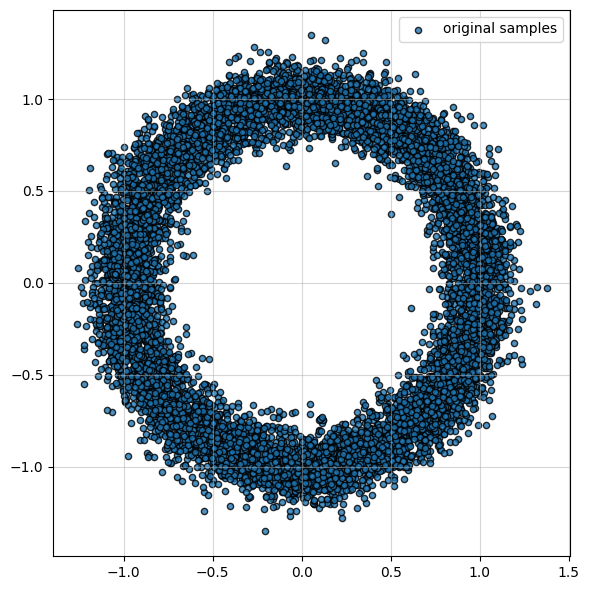

In [5]:
nb_samples = 10000
radius = 1
nz = .1
# generate the data
X_train = torch.zeros((nb_samples, 2))
r = radius + nz*torch.randn(nb_samples)
theta = torch.rand(nb_samples)*2*torch.pi
X_train[:, 0] = r*torch.cos(theta)
X_train[:, 1] = r*torch.sin(theta)

plt.figure(figsize=(6, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], s=20, alpha=0.8, edgecolor='k', marker='o', label='original samples')
plt.grid(alpha=0.5)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [6]:
def generate_images(generator_model, noise_dim, num_samples=1000, ax=None):
    with torch.no_grad():
        z = torch.Tensor(np.random.normal(0, 1, (num_samples, noise_dim))).type(torch.float32)
        predicted_samples = generator_model(z)
    created_ax = False
    if ax is None:
        plt.close('all')
        fig, ax = plt.subplots(figsize=(6, 6))
        created_ax = True
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="You passed a edgecolor/edgecolors .* for an unfilled marker.*")
        ax.scatter(X_train[:, 0], X_train[:, 1], s=40, alpha=0.2, edgecolor='k', marker='+', label='original samples')
    ax.scatter(predicted_samples[:, 0], predicted_samples[:, 1], s=10,
               alpha=0.9, c='r', edgecolor='k', marker='o', label='predicted')
    ax.grid(alpha=0.5)
    ax.legend(loc='best')
    if created_ax:
        plt.tight_layout()
        plt.show()

class Generator(nn.Module):
    def __init__(self, noise_dim=10):
        super(Generator, self).__init__()
        self.noise_dim = noise_dim
        self.model = nn.Sequential(
            nn.Linear(self.noise_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
        )

    def forward(self, z):
        return self.model(z)


class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.model(x)

In [7]:
def plot_discriminator(discriminator, bounds = [(-1.5, 1.5), (-1.5, 1.5)], ax=None):
    with torch.no_grad():
        x = torch.linspace(bounds[0][0], bounds[0][1], 100)
        y = torch.linspace(bounds[1][0], bounds[1][1], 100)
        X, Y = torch.meshgrid(x, y)
        Z = discriminator(torch.cat((X.reshape(-1, 1), Y.reshape(-1, 1)), dim=1)).reshape(X.shape)
    created_ax = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
        created_ax = True
    cont = ax.contourf(X, Y, Z, alpha=0.5)
    plt.colorbar(cont, ax=ax)
    if created_ax:
        plt.show()

In [8]:
# Initialize generator and discriminator
noise_dim = 2
generator = Generator(noise_dim=noise_dim)
discriminator = Discriminator()

# Optimizers
lr_G = 0.001
lr_D = 0.001
n_epochs = 36  # 500
clip_value = 0.3
n_critic = 5
batch_size = 128
optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr_G, betas=(0.5, 0.9))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr_D, betas=(0.5, 0.9))
dataloader = DataLoader(X_train, batch_size, shuffle=True)
batches_done = 0

gen_fig, gen_axs = plt.subplots(2, 4, figsize=(20, 8))
gen_axs = gen_axs.flatten()

disc_fig, disc_axs = plt.subplots(2, 4, figsize=(20, 8))
disc_axs = disc_axs.flatten()

for epoch in range(n_epochs):
    for i, x in enumerate(dataloader):
        bs = x.shape[0]
        # Configure input
        x = x.type(torch.float32)
        # ---------------------
        #  Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()

        # Sample noise as generator input
        z = #TODO

        # Generate a batch of images
        fake_x = #TODO
        # Adversarial loss
        loss_D = 

        # Compute the gradient of the loss
        loss_D.backward()
        # Make an optimizer step
        optimizer_D.step()

        # Clip weights of discriminator
        # TODO

        # Train the generator every n_critic iterations
        if i % n_critic == 0:
            # -----------------
            #  Train Generator
            # -----------------
            optimizer_G.zero_grad()

            # Generate a batch of images
            z = # TODO
            fake_x = #TODO
            loss_G = #TODO

            # Compute the gradient of the loss
            loss_G.backward()
            # Make an optimizer step
            optimizer_G.step()

    # Visualization of intermediate results
    if (epoch) % 5 == 0:
        print("Epoch: ", epoch)
        generate_images(generator, noise_dim, ax=gen_axs[(epoch) // 5])
        plot_discriminator(discriminator, ax=disc_axs[(epoch) // 5])
        gen_axs[(epoch) // 5].set_title("Epoch: " + str(epoch))
        disc_axs[(epoch) // 5].set_title("Epoch: " + str(epoch))

gen_fig.suptitle("Generator samples")
disc_fig.suptitle("Discriminator certainty")

SyntaxError: invalid syntax (1939302837.py, line 35)

We can see that that the generator has learnt to produce points from the annulus, albeit slightly biased and not perfectly symmetrically, and that the discriminator penalizes points that are produced in the interior of the annulus. Interestingly it is somewhat agnostic or even favorful to points outside the annulus.

In [9]:
def compute_gradient_penalty(D, real_samples, fake_samples):
    """Calculates the gradient penalty loss for WGAN GP"""
    # Random weight term for interpolation between real and fake samples
    alpha = #TODO
    # Get random interpolation between real and fake samples
    interpolates = #TODO
    d_interpolates = #TODO
    # Get gradient w.r.t. interpolates
    gradients = #TODO
    gradient_penalty = #TODO
    return gradient_penalty

SyntaxError: invalid syntax (139718339.py, line 4)

In [10]:
# Initialize generator and discriminator
noise_dim = 2
generator = Generator(noise_dim=noise_dim)
discriminator = Discriminator()

# Optimizers
lr_G = 0.0001
lr_D = 0.001
n_epochs = 211  # 500
lambda_gp = 1.0
n_critic = 5
batch_size = 128
optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr_G, betas=(0.5, 0.9))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr_D, betas=(0.5, 0.9))
dataloader = DataLoader(X_train, batch_size, shuffle=True)
batches_done = 0

gen_fig, gen_axs = plt.subplots(2, 4, figsize=(20, 8))
gen_axs = gen_axs.flatten()

disc_fig, disc_axs = plt.subplots(2, 4, figsize=(20, 8))
disc_axs = disc_axs.flatten()

for epoch in range(n_epochs):
    for i, x in enumerate(dataloader):
        bs = x.shape[0]
        # Configure input
        x = x.type(torch.float32)
        # ---------------------
        #  Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()

        # Sample noise as generator input
        z = #TODO

        # Generate a batch of images
        fake_x = #TODO
        # Adversarial loss
        gradient_penalty = #TODO
        loss_D = #TODO

        loss_D.backward()
        optimizer_D.step()


        # Train the generator every n_critic iterations
        if i % n_critic == 0:
            # -----------------
            #  Train Generator
            # -----------------

            optimizer_G.zero_grad()

            # Generate a batch of images
            z = #TODO
            fake_x = #TODO
            # Adversarial loss
            loss_G = #TODO

            loss_G.backward()
            optimizer_G.step()

        batches_done += 1

    # Visualization of intermediate results
    if epoch % 30 == 0:
        print("Epoch: ", epoch)
        generate_images(generator, noise_dim, ax=gen_axs[(epoch) // 30])
        plot_discriminator(discriminator, ax=disc_axs[(epoch) // 30])
        gen_axs[(epoch) // 30].set_title("Epoch: " + str(epoch))
        disc_axs[(epoch) // 30].set_title("Epoch: " + str(epoch))

gen_fig.suptitle("Generator samples")
disc_fig.suptitle("Discriminator certainty")

SyntaxError: invalid syntax (854074194.py, line 35)

With the gradient penalty, the generator taes longer to converge, but the generated distribution is more symmetrical, however has a greater tendency to be within the annulus.

The gradient penalty trained critic looks more Lipschitz than the clipped critic, reflecting the success of its training. However it penalizes much less points that are within the annulus.

We can also see that early in the critic training (epoch 30), the critic judges the annulus highly, compared to all other points. As training progresses, the critic flattens.